In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#2026/01/28 Test reflex for pure Python
# code from EA.py main

In [3]:
import os, sys
import numpy as np
from EA import load_ri, ML_reflex
from matplotlib import pyplot as plt

In [4]:
# data for reflex tests
folder = '.'
datafolder=r'.\data\test_reflex' #os.path.dirname(os.path.abspath('.')) #((sys.argv[1]))  #project name

#set system
h_c=12.39841857 
linestyles=[ '-',':','-.','--']
colors="bgrcmyk"

In [5]:
pwd

'g:\\My Drive\\progetti\\POOL\\coating_opt\\fortran\\EA'

Film structure can be read from IMD file with the following code.
`materials`, `dspacing`, and `roughness` are loaded.

In [6]:
# Read the CSV file
coat_file = os.path.join(datafolder,r'IMDformats\a_C_PtML.txt')
materials, dspacing, roughness = np.genfromtxt(coat_file, delimiter='', names=True, dtype=None, encoding='utf-8',comments = ';', usecols = [1,2,3], unpack=True)

materials, dspacing, roughness

(array(['a-C', 'Pt', 'a-C', 'Pt', 'a-C', 'Pt', 'a-C', 'Pt', 'Ni'],
       dtype='<U3'),
 array([70., 30., 70., 30., 70., 30., 70., 30.,  0.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0.]))

Main parameters are energy and refractive indices dictionary (as interpolators).
They can be converted to a list of refractive indices for each material with a convenience function `mat2indices`.


In [7]:
from EA import mat2indices

In [8]:
#main parameters
ener = np.linspace( 0.1,40,100)

riDic=load_ri(['a-C','Au','Ni','Pt','Cr','Ir','C8H11NO2_llnl_cxro'] )  # dictionary of interpolators with all materials of interest
riDic


{'Au': <scipy.interpolate._interpolate.interp1d at 0x1d18fc41d60>,
 'C8H11NO2_llnl_cxro': <scipy.interpolate._interpolate.interp1d at 0x1d18f3566c0>,
 'Cr': <scipy.interpolate._interpolate.interp1d at 0x1d18fd3e9e0>,
 'Ir': <scipy.interpolate._interpolate.interp1d at 0x1d18fd3ea80>,
 'Ni': <scipy.interpolate._interpolate.interp1d at 0x1d18fd3eb70>,
 'Pt': <scipy.interpolate._interpolate.interp1d at 0x1d18fd3ec60>,
 'a-C': <scipy.interpolate._interpolate.interp1d at 0x1d18cad6da0>}

## Simulations and comparison with test data

`ML_reflex` functions accept a lists of materials and thickness for each layer.
`thickness = None` identifies the substrate.

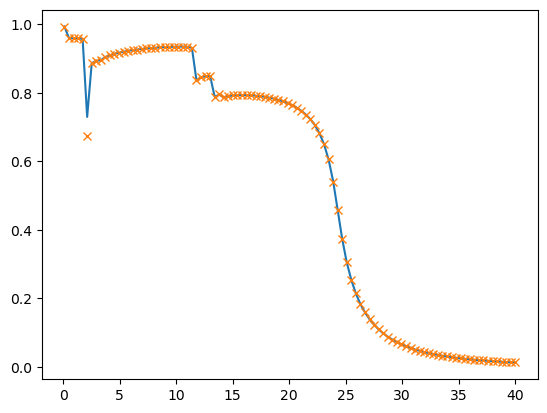

In [9]:
# test single layer 

angles = [0.2]
materials, dspacing, roughness = ['Pt'] , [None], 0

indices = mat2indices(materials, riDic, ener)
ref = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles[0]*np.pi/180, rough=0, indices=indices)
plt.plot(ener, ref)

e,r = np.genfromtxt(os.path.join(datafolder,r'IMDsimulations\Pt_0.2deg.txt'), comments=';',unpack=True)
plt.plot(e,r,'x')



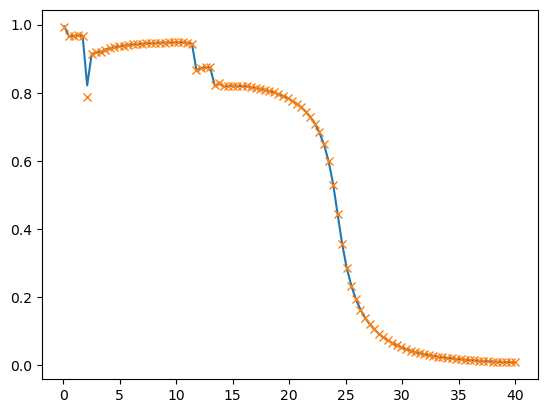

In [10]:
# test double layer 

angles = [0.2]
materials, dspacing, roughness = ['a-C','Pt'] , [20, None], 0

indices = mat2indices(materials, riDic, ener)
ref = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles[0]*np.pi/180, rough=0, indices=indices)
plt.plot(ener, ref)

e,r = np.genfromtxt(os.path.join(datafolder,r'IMDsimulations\PtC_0.2deg.txt'), comments=';',unpack=True)
plt.plot(e,r,'x')



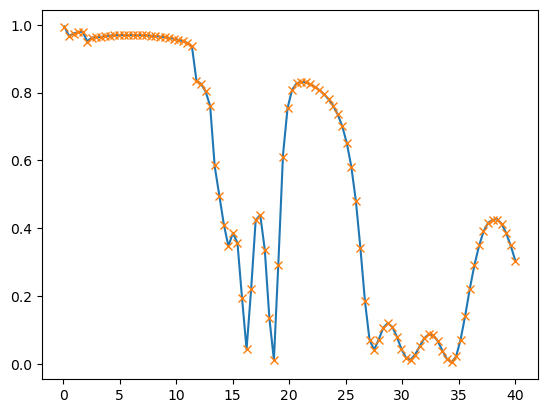

In [11]:
# test multilayer 

angles = [0.2]

# Read the CSV file
coat_file = os.path.join(datafolder,r'IMDformats\a_C_PtML.txt')
materials, dspacing, roughness = np.genfromtxt(coat_file, delimiter='', names=True, dtype=None, encoding='utf-8',comments = ';', usecols = [1,2,3], unpack=True)

materials, dspacing, roughness


materials = ['a-C','Pt','a-C','Pt','a-C','Pt','a-C','Pt','Ni'] 
dspacing = [70,30,70,30,70,30,70,30, None]
roughness =  0

indices = mat2indices(materials, riDic, ener)
ref = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles[0]*np.pi/180, rough=0, indices=indices)
plt.plot(ener, ref)

e,r = np.genfromtxt(os.path.join(datafolder,r'IMDsimulations\PtCML_0.2deg.txt'), comments=';',unpack=True)
plt.plot(e,r,'x')



Text(0, 0.5, 'Angle (deg)')

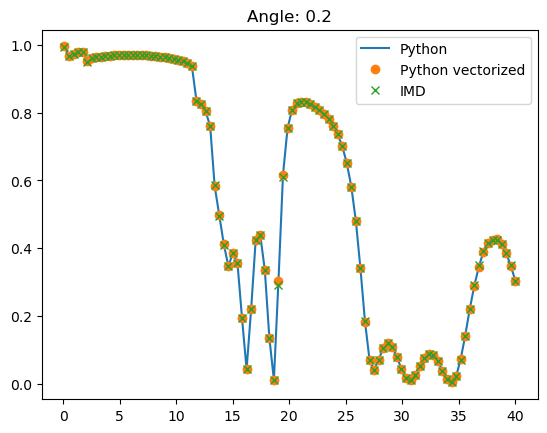

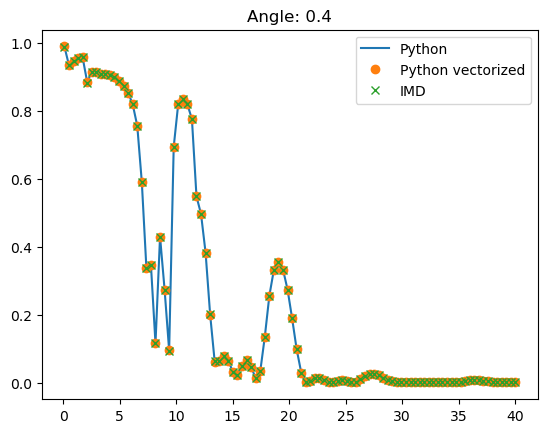

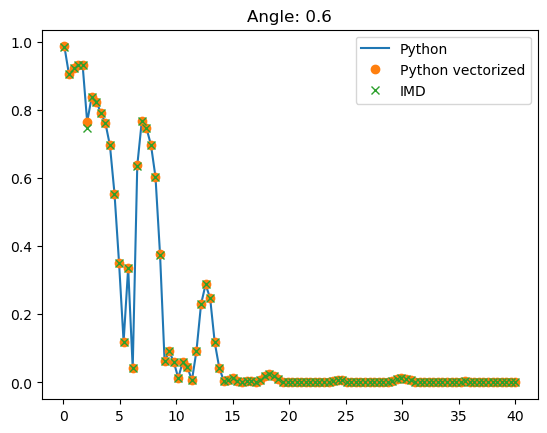

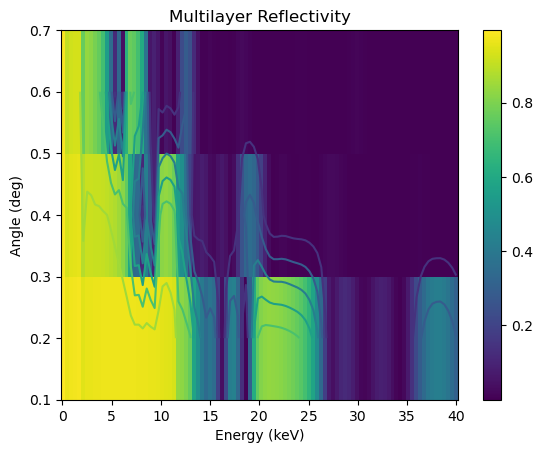

In [ ]:
# test multilayer vector angle 

angles = [0.2, 0.4, 0.6]

materials = ['a-C','Pt','a-C','Pt','a-C','Pt','a-C','Pt','Ni'] 
dspacing = [70,30,70,30,70,30,70,30, None]
roughness =  0

indices = mat2indices(materials, riDic, ener)

ref_vec = ML_reflex(d_spacing=dspacing, ener=ener, angle=[a*np.pi/180 for a in angles], rough=0, indices=indices)

for a,rv in zip(angles, ref_vec):
    plt.figure()
    plt.title("Angle: %2.1f" % a)
    ref = ML_reflex(d_spacing=dspacing, ener=ener, angle=a*np.pi/180, rough=0, indices=indices)
    plt.plot(ener, ref, label = 'Python')
    plt.plot(ener, rv, 'o',label = 'Python vectorized')

    e,r = np.genfromtxt(os.path.join(datafolder,r'IMDsformats\PtCML_%2.1fdeg.txt'%a), comments=';',unpack=True)
    plt.plot(e,r,'x', label = 'IMD')
    plt.legend()

plt.figure()
from pySurf.data2D import plot_data

plot_data(ref_vec, x=ener, y=angles, title='Multilayer Reflectivity',aspect='auto',contour=True)
plt.xlabel('Energy (keV)')
plt.ylabel('Angle (deg)')

## Combining multi angle reflectivity into telescope area

Reads a structure file. Angles and acoll are needed.

In [14]:
from pySurf.data2D import plot_data

In [12]:
#calculate telescope area

shellfile = os.path.join(datafolder,r'Design_EXPO5.mms')

angles,acoll = np.genfromtxt(shellfile,skip_header=1,delimiter='\t',unpack=True,usecols=(5,6)) #angles in rad

angles = angles [::-1]  # this is needed only for correct axis orientation in plot_data
acoll = acoll [::-1]

Text(0, 0.5, 'Angle (deg)')

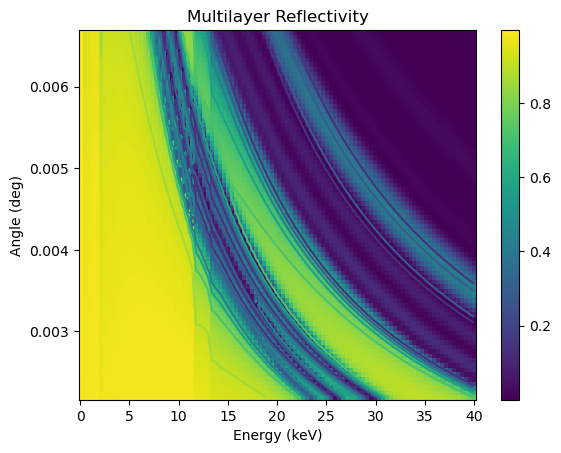

In [15]:
materials = ['a-C','Pt','a-C','Pt','a-C','Pt','a-C','Pt','Ni'] 
dspacing = [70,30,70,30,70,30,70,30, None]
roughness =  0

indices = mat2indices(materials, riDic, ener)

ref_vec = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles, rough=0, indices=indices)

plot_data(ref_vec, x=ener, y=angles, title='Multilayer Reflectivity',aspect='auto',contour=True,axis_check=False)
plt.xlabel('Energy (keV)')
plt.ylabel('Angle (deg)')

#qui con contour si vede che la figura è ribaltata. Questo perché span_from_pixels ritorna risultato ordinato
#indipendentemente dal verso dell'input.

In [16]:
#reproduce spiga

simarea = os.path.join(datafolder,r'Simulated_effective_area_LowEN_AuC.txt')
esim,asim = np.genfromtxt(simarea, skip_header=50,comments = '%',usecols=(0,1),unpack=True)

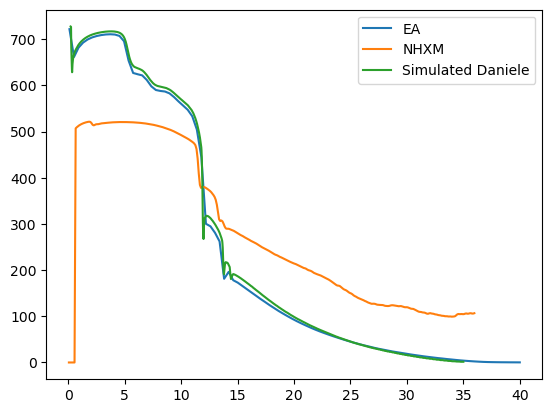

In [17]:
materials = ['a-C','Au','Ni'] 
dspacing = [300,1000, None]
roughness =  4

indices = mat2indices(materials, riDic, ener)

ref_vec = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles, rough=0, indices=indices)

atot = np.sum(ref_vec**2 * acoll[:,np.newaxis]*0.9, axis=0)

plt.plot(ener,atot, label='EA')


e,a = np.genfromtxt(os.path.join(datafolder,r'EA_NHXM_ref.txt'),skip_header=1,delimiter='\t',unpack=True  )

plt.plot(e,a,label = 'NHXM')
plt.plot(esim,asim,label = 'Simulated Daniele')

plt.legend()

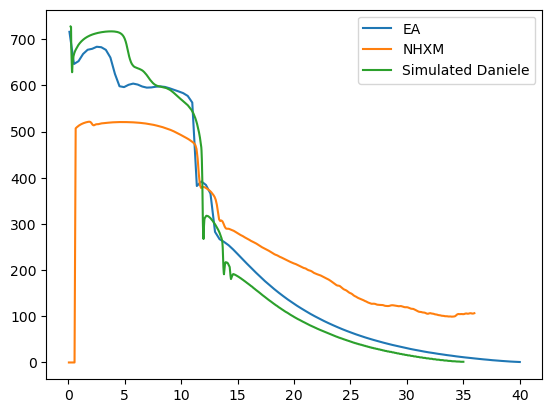

In [25]:
materials = ['C8H11NO2_llnl_cxro','Ir','Ni'] 
dspacing = [300,1000, None]
roughness =  4

indices = mat2indices(materials, riDic, ener)

ref_vec = ML_reflex(d_spacing=dspacing, ener=ener, angle=angles, rough=0, indices=indices)

atot = np.sum(ref_vec**2 * acoll[:,np.newaxis]*0.9, axis=0)

plt.plot(ener,atot, label='EA')


e,a = np.genfromtxt(os.path.join(datafolder,r'EA_NHXM_ref.txt'),skip_header=1,delimiter='\t',unpack=True  )

plt.plot(e,a,label = 'NHXM')
plt.plot(esim,asim,label = 'Simulated Daniele')

plt.legend()